# ⚽ Football Analytics with Python
## Chapter 10 — Heat Maps

**BarcaFutbol Analytics Course · HackrLife Media LLC**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HackrLife/Football-Analytics/blob/main/The-Football-Analytics-Course/Chapter-10-Heat-Maps/Chapter_10_Heat_Maps.ipynb)

---

A heat map turns a grid of numbers into a grid of colours. Every cell in the
grid gets a colour proportional to its value — and the human brain reads colour
differences faster than it reads numbers. A grid of 110 numbers is hard to scan.
The same grid coloured from red (low) to green (high) tells its story in two seconds.

Football analytics uses heat maps in three ways. This chapter teaches all three:

1. **Performance over time** — player ratings across 10 matches, showing form and consistency
2. **Team comparison matrix** — multiple metrics across multiple teams in one grid
3. **Data completeness audit** — the quality check from Chapter 2, now taught as a technique

### What You Will Build

**Part 1:** Match-by-match performance heat map — 11 players × 10 matches
**Part 2:** Annotated heat map — values printed inside cells
**Part 3:** The `build_heatmap()` template — any grid, any colour scale

---
*Course GitHub: [github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

In [1]:
!pip install pandas matplotlib numpy scipy --quiet
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats
%matplotlib inline
plt.rcParams['figure.dpi']=150
print("✓ Ready.")

✓ Ready.


In [1]:
BG='#0d1117'; BG2='#0d1b2a'; BG3='#161b22'
WHITE='#f0f6fc'; GRAY='#8b949e'; GOLD='#EDBB00'
GREEN='#4CAF50'; YELLOW='#ffd60a'; ORANGE='#FF9800'; RED='#e63946'
TIER_COLORS={'Elite':GREEN,'Above Average':YELLOW,'Average':ORANGE,'Below Average':RED}
PLAYER_COLORS={'Marcus Silva':'#3498DB','Lucas Ferreira':'#2ecc71',
    'James Thornton':'#e74c3c','Diego Varela':'#9B59B6','Amir Hassan':'#FF9800',
    'Kai Becker':'#00BCD4','Tom Wheeler':'#F06292','Sam Okafor':'#80CBC4',
    'Elena Rossi':'#FFD54F','Carlos Mendez':'#CE93D8','Jin Park':'#A5D6A7'}
def style_axis(ax,theme='dark',xlabel=None,ylabel=None,title=None,subtitle=None):
    bg=BG if theme=='dark' else '#f8f9fa'
    tc=WHITE if theme=='dark' else '#1a1a2e'
    gc=WHITE if theme=='dark' else '#cccccc'
    sc=GRAY if theme=='dark' else '#888888'
    ax.set_facecolor(bg)
    ax.spines['bottom'].set_color(sc); ax.spines['left'].set_color(sc)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(colors=tc,labelsize=10)
    ax.grid(True,alpha=0.07,color=gc,linewidth=0.8)
    if xlabel: ax.set_xlabel(xlabel,color=tc,fontsize=11,labelpad=8)
    if ylabel: ax.set_ylabel(ylabel,color=tc,fontsize=11,labelpad=8)
    if title and subtitle:
        ax.set_title(title+'\n'+subtitle,color=tc,fontsize=13,fontweight='bold',pad=15,linespacing=1.6)
    elif title: ax.set_title(title,color=tc,fontsize=13,fontweight='bold',pad=12)
    return ax
print("✓ Design system loaded.")

✓ Design system loaded.


In [1]:
df=pd.read_csv('data/chapter10_heatmap.csv')
print(f'Shape: {df.shape}')
print(df.to_string(index=False))

Shape: (11, 11)
        player  match_1  match_2  match_3  match_4  match_5  match_6  match_7  match_8  match_9  match_10
  Marcus Silva      7.8      6.2      8.1      7.4      9.0      6.8      7.2      8.4      7.6       8.9
Lucas Ferreira      7.1      7.8      6.9      8.2      7.5      8.0      7.4      6.8      8.1       7.9
James Thornton      6.5      7.2      7.8      6.4      7.9      8.2      7.0      7.5      6.8       8.0
  Diego Varela      7.4      6.8      7.1      7.6      6.9      7.3      8.0      7.2      6.5       7.0
   Amir Hassan      8.0      7.5      7.2      8.4      7.8      7.1      8.2      7.9      8.5       7.6
    Kai Becker      6.8      7.4      6.5      7.2      7.8      6.9      7.1      6.8      7.5       7.3
   Tom Wheeler      7.2      8.1      7.5      7.9      8.3      7.6      7.8      8.0      7.4       7.7
    Sam Okafor      5.9      6.8      7.2      6.5      7.0      6.2      6.8      7.1      6.4       6.9
   Elena Rossi      6.4      6

---
## Part 1 — Basic Heat Map

A heat map is built from `plt.Rectangle` patches — one per cell — coloured using a colourmap (`cmap`). The `plt.Normalize()` function maps the data range to the 0–1 colour scale.

```python
cmap = plt.cm.RdYlGn          # red → yellow → green
norm = plt.Normalize(5.5, 9.5) # map ratings 5.5-9.5 to colour scale
colour = cmap(norm(value))     # get RGBA colour for this value
```

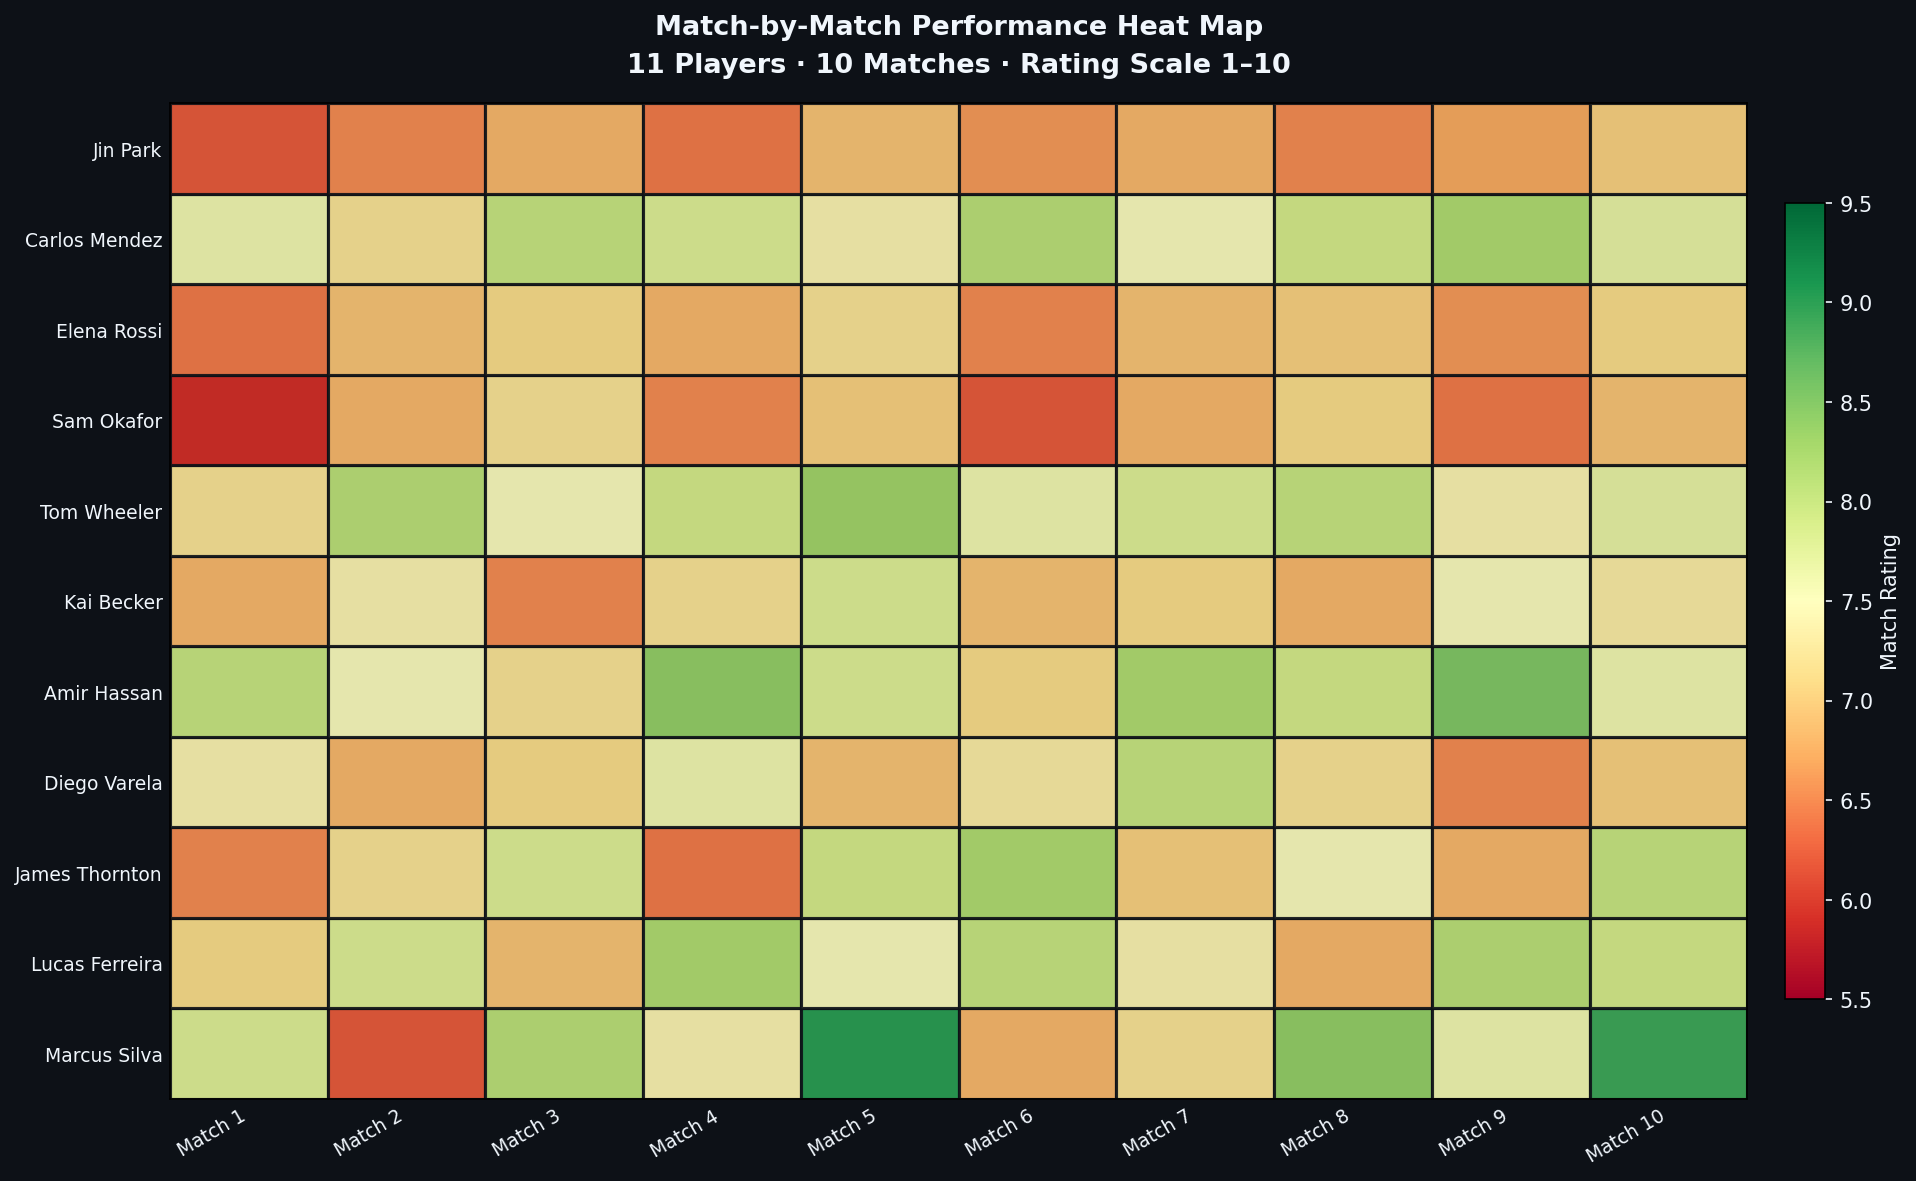

In [1]:
match_cols  = [f'match_{i}' for i in range(1, 11)]
player_list = list(df['player'])

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

# Colour map: red (low) → yellow (mid) → green (high)
cmap = plt.cm.RdYlGn
norm = plt.Normalize(vmin=5.5, vmax=9.5)

# Draw one rectangle per cell
for i, player in enumerate(player_list):
    for j, col in enumerate(match_cols):
        val   = df.loc[df['player'] == player, col].values[0]
        color = cmap(norm(val))     # maps 5.5-9.5 → red-yellow-green

        rect = plt.Rectangle(
            [j, i], 1, 1,           # (x, y), width, height
            facecolor=color,
            edgecolor=BG,           # cell border matches background
            linewidth=1.5,
            alpha=0.90
        )
        ax.add_patch(rect)

# Axes
ax.set_xlim(0, 10); ax.set_ylim(0, len(player_list))
ax.set_xticks([x + 0.5 for x in range(10)])
ax.set_xticklabels([f'Match {i}' for i in range(1, 11)],
                   color=WHITE, fontsize=9, rotation=30, ha='right')
ax.set_yticks([y + 0.5 for y in range(len(player_list))])
ax.set_yticklabels(player_list, color=WHITE, fontsize=9)
ax.tick_params(length=0)

# Colour bar — shows the scale
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
cb.set_label('Match Rating', color=WHITE, fontsize=10)
cb.ax.yaxis.set_tick_params(color=WHITE)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=WHITE)

ax.set_title('Match-by-Match Performance Heat Map\n'
             '11 Players · 10 Matches · Rating Scale 1–10',
             color=WHITE, fontsize=13, fontweight='bold', pad=15, linespacing=1.6)
plt.tight_layout()
plt.show()

---
## Part 2 — Annotated Heat Map

Print the exact value inside each cell. The key challenge: text colour must switch automatically between dark (on bright cells) and white (on dark cells), otherwise labels disappear into the background.

```python
# Luminance formula — measures perceived brightness
luminance = 0.299*R + 0.587*G + 0.114*B
text_color = '#111111' if luminance > 0.5 else WHITE
```

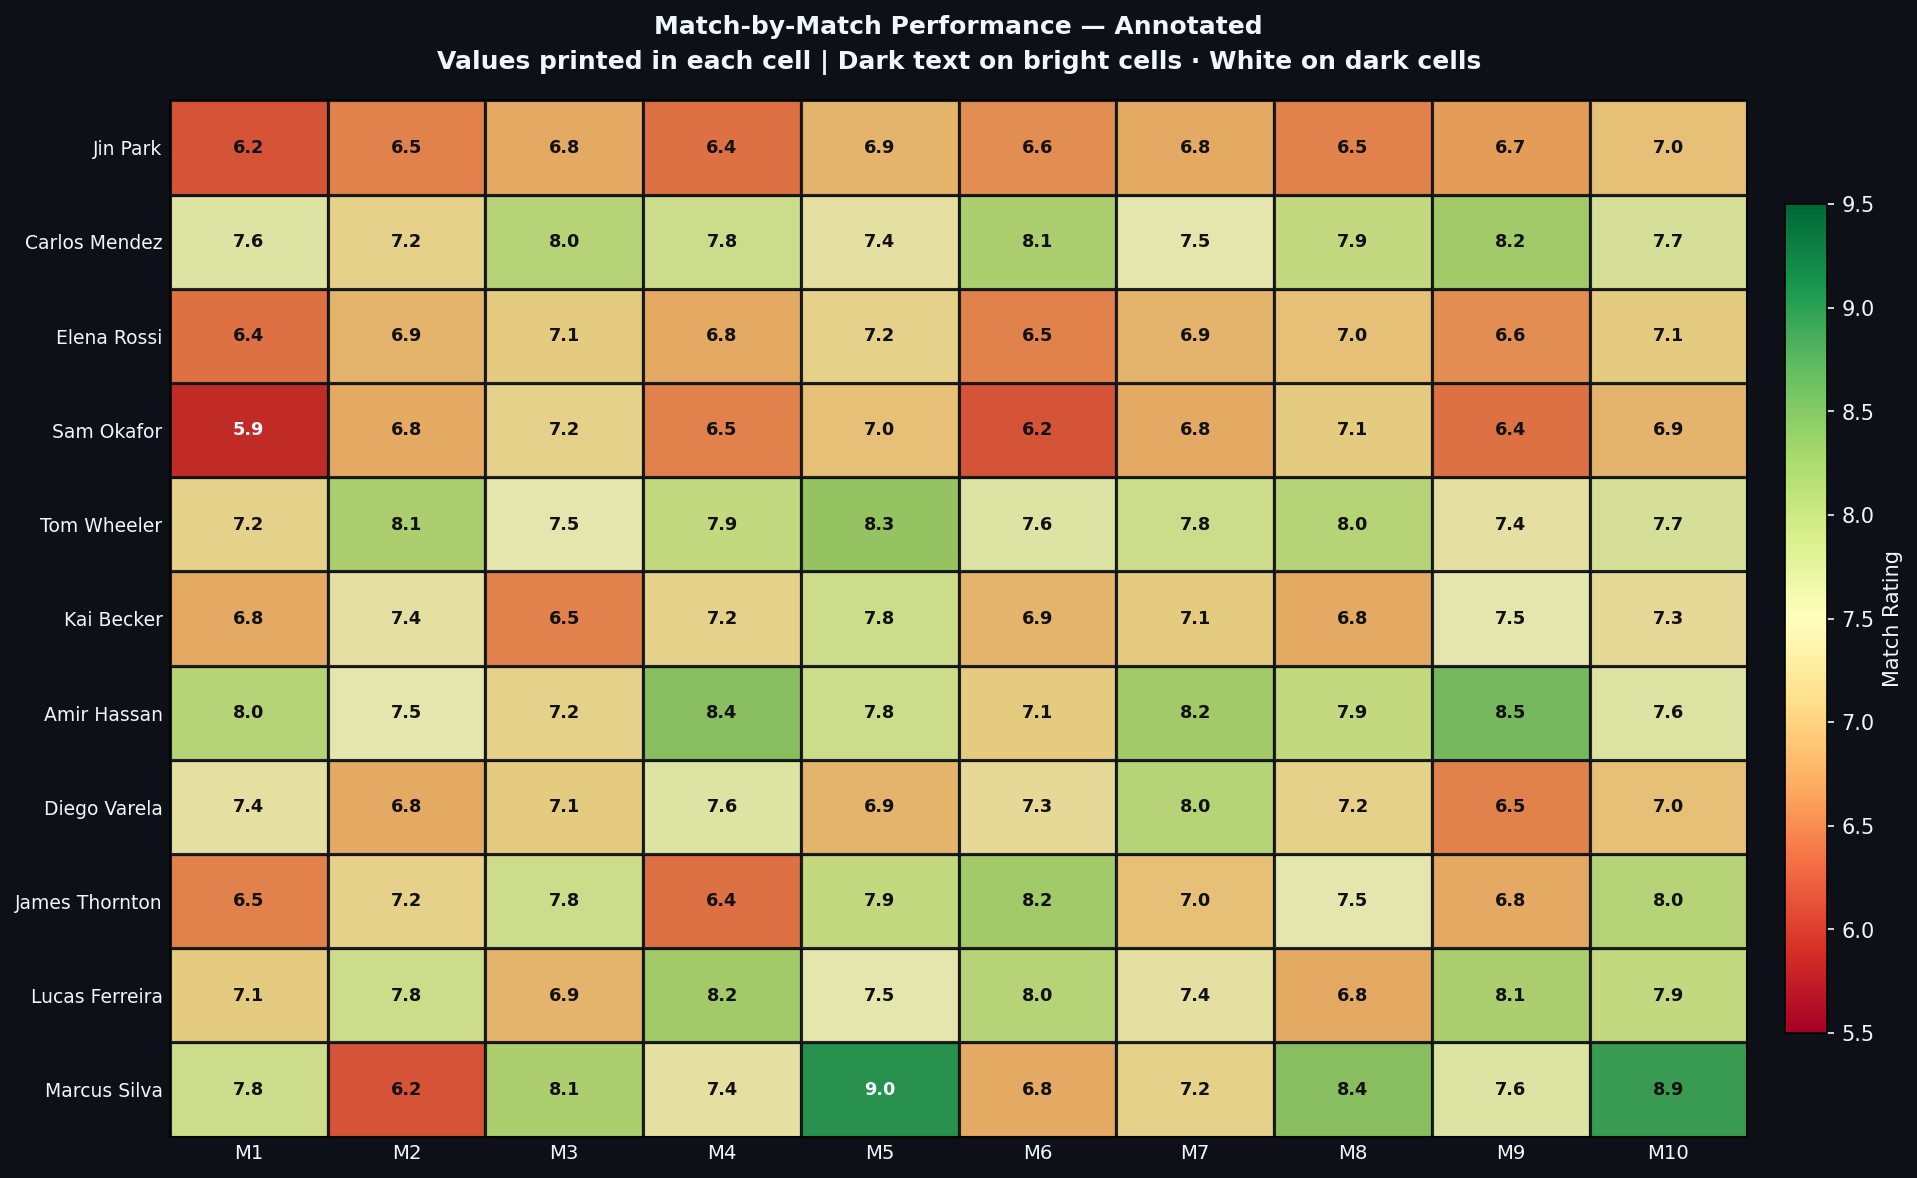


Consistency analysis (std dev of ratings — lower = more consistent):
        player  avg  std  peak
   Amir Hassan 7.82 0.48   8.5
   Tom Wheeler 7.75 0.34   8.3
  Marcus Silva 7.74 0.89   9.0
 Carlos Mendez 7.74 0.32   8.2
Lucas Ferreira 7.57 0.51   8.2
James Thornton 7.33 0.64   8.2
  Diego Varela 7.18 0.43   8.0
    Kai Becker 7.13 0.39   7.8
   Elena Rossi 6.85 0.27   7.2
    Sam Okafor 6.68 0.42   7.2
      Jin Park 6.64 0.25   7.0


In [1]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

cmap = plt.cm.RdYlGn
norm = plt.Normalize(vmin=5.5, vmax=9.5)

for i, player in enumerate(player_list):
    for j, col in enumerate(match_cols):
        val   = df.loc[df['player'] == player, col].values[0]
        color = cmap(norm(val))

        rect = plt.Rectangle([j, i], 1, 1,
                              facecolor=color, edgecolor=BG,
                              linewidth=1.5, alpha=0.90)
        ax.add_patch(rect)

        # Automatic text colour — dark on bright cells, white on dark cells
        # Luminance formula (ITU-R BT.601) measures perceived brightness
        luminance  = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
        text_color = '#111111' if luminance > 0.5 else WHITE

        ax.text(j + 0.5, i + 0.5, f'{val:.1f}',
                ha='center', va='center',
                fontsize=8.5, color=text_color, fontweight='bold')

ax.set_xlim(0, 10); ax.set_ylim(0, len(player_list))
ax.set_xticks([x + 0.5 for x in range(10)])
ax.set_xticklabels([f'M{i}' for i in range(1, 11)], color=WHITE, fontsize=9.5)
ax.set_yticks([y + 0.5 for y in range(len(player_list))])
ax.set_yticklabels(player_list, color=WHITE, fontsize=9)
ax.tick_params(length=0)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cb = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
cb.set_label('Match Rating', color=WHITE, fontsize=10)
cb.ax.yaxis.set_tick_params(color=WHITE)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=WHITE)

ax.set_title('Match-by-Match Performance — Annotated\n'
             'Values printed in each cell | Auto text colour for readability',
             color=WHITE, fontsize=12, fontweight='bold', pad=15, linespacing=1.6)
plt.tight_layout()
plt.show()

# Print consistency stats
print("\nConsistency analysis (std dev of ratings — lower = more consistent):")
df_stats = df.copy()
df_stats['avg']  = df_stats[match_cols].mean(axis=1).round(2)
df_stats['std']  = df_stats[match_cols].std(axis=1).round(2)
df_stats['peak'] = df_stats[match_cols].max(axis=1).round(2)
print(df_stats[['player','avg','std','peak']].sort_values('avg',ascending=False).to_string(index=False))

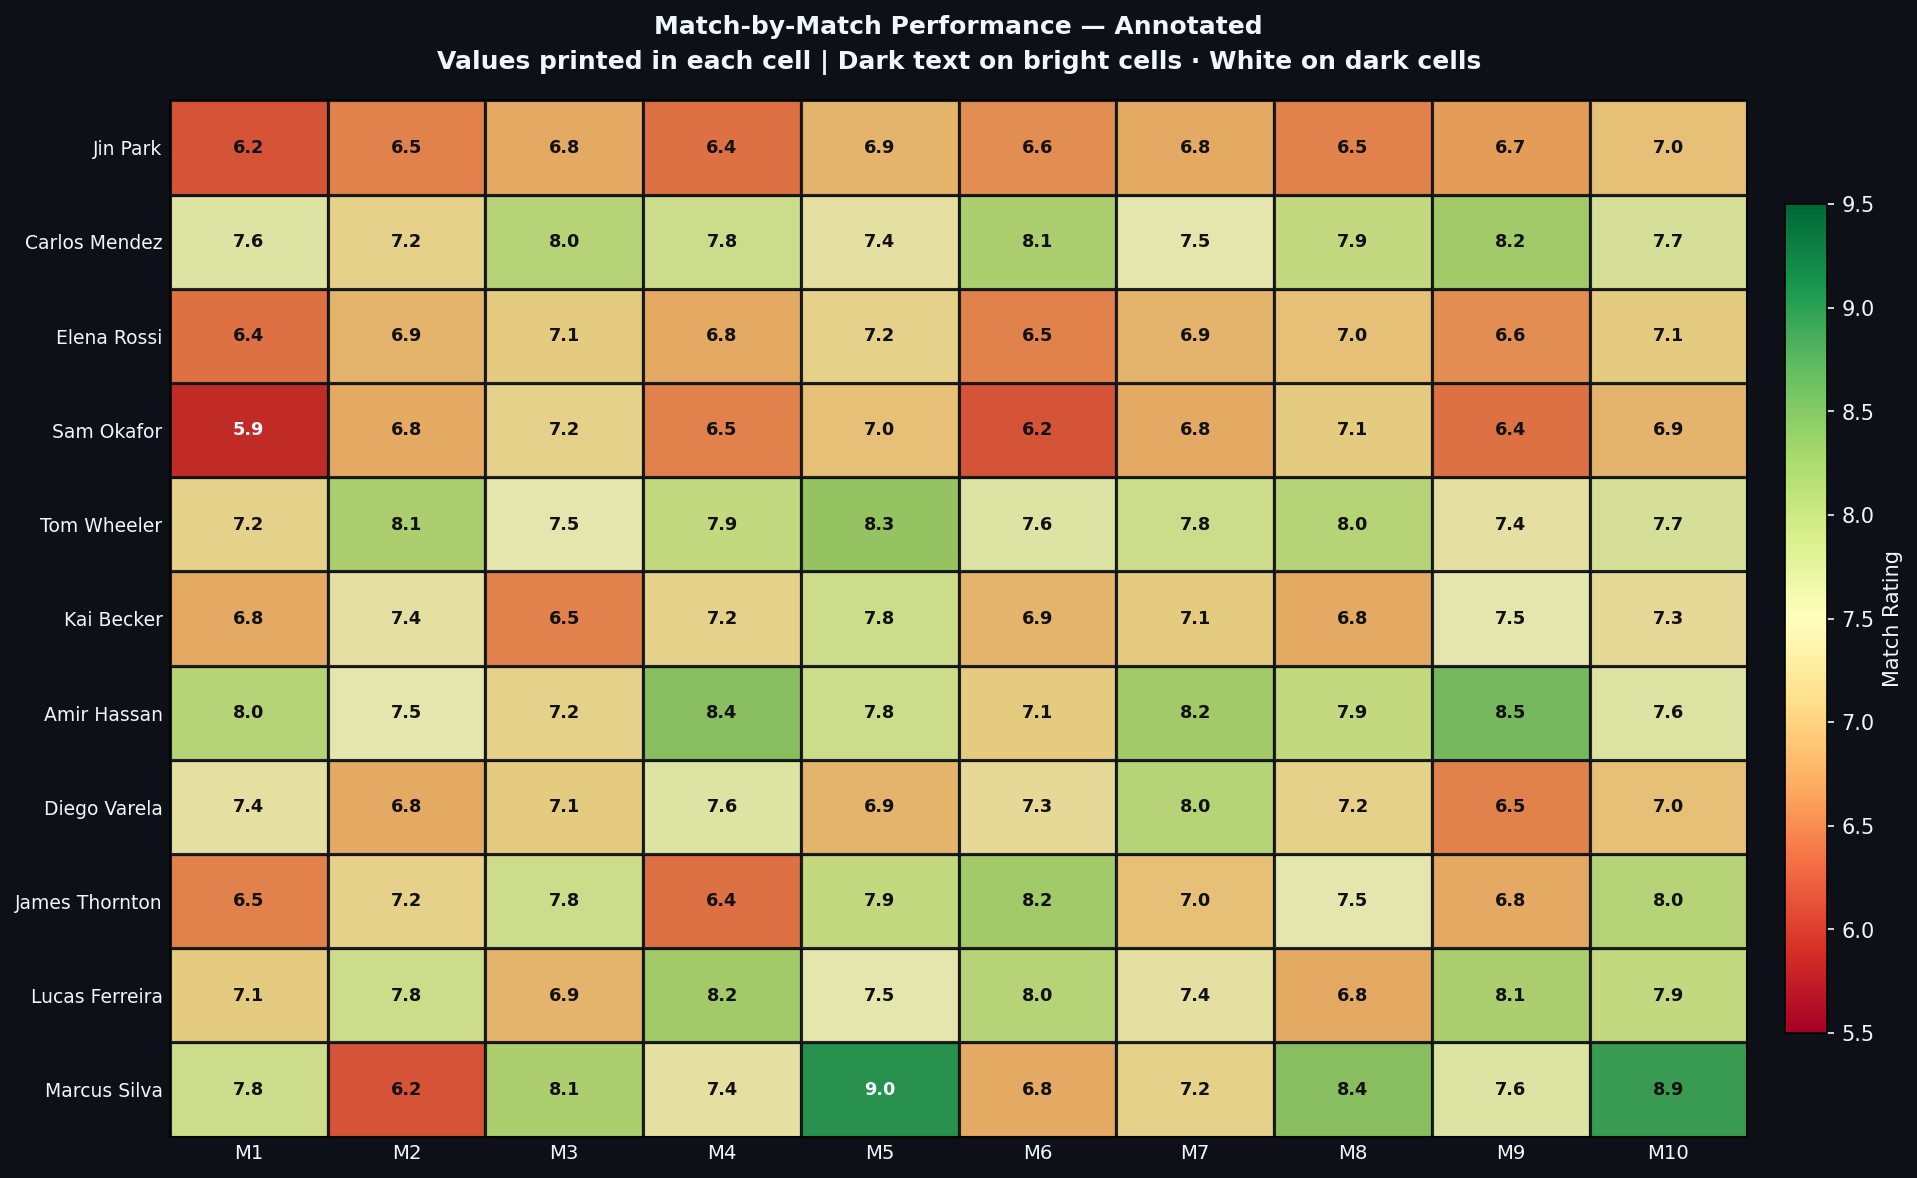

✓ build_heatmap() template working.


In [1]:
# THE REUSABLE TEMPLATE
def build_heatmap(data_df, value_cols, row_label_col='player',
                  cmap_name='RdYlGn', vmin=None, vmax=None,
                  annotate=True, title='', subtitle='',
                  col_labels=None, figsize=(14, 8)):
    """
    Build a publication-ready annotated heat map.

    Parameters
    ----------
    data_df       : DataFrame containing the data
    value_cols    : list[str] — columns to use as heat map cells
    row_label_col : str — column to use as row labels (default: 'player')
    cmap_name     : str — matplotlib colourmap (default: 'RdYlGn')
    vmin, vmax    : float — colour scale range (auto if None)
    annotate      : bool — print values inside cells
    title, subtitle : str
    col_labels    : list[str] — custom column header labels
    figsize       : tuple

    Returns: fig, ax
    """
    rows  = list(data_df[row_label_col])
    n_rows, n_cols = len(rows), len(value_cols)

    vmin  = vmin or data_df[value_cols].min().min()
    vmax  = vmax or data_df[value_cols].max().max()
    cmap  = plt.cm.get_cmap(cmap_name)
    norm  = plt.Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

    for i, row_label in enumerate(rows):
        for j, col in enumerate(value_cols):
            val   = data_df.loc[data_df[row_label_col]==row_label, col].values[0]
            color = cmap(norm(val))
            ax.add_patch(plt.Rectangle([j, i], 1, 1,
                         facecolor=color, edgecolor=BG,
                         linewidth=1.5, alpha=0.90))
            if annotate:
                lum = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
                tc  = '#111111' if lum > 0.5 else WHITE
                ax.text(j+0.5, i+0.5,
                        f'{val:.1f}' if isinstance(val, float) else str(val),
                        ha='center', va='center',
                        fontsize=8.5, color=tc, fontweight='bold')

    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows)
    labels = col_labels or value_cols
    ax.set_xticks([x+0.5 for x in range(n_cols)])
    ax.set_xticklabels(labels, color=WHITE, fontsize=9, rotation=30, ha='right')
    ax.set_yticks([y+0.5 for y in range(n_rows)])
    ax.set_yticklabels(rows, color=WHITE, fontsize=9)
    ax.tick_params(length=0)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
    cb.ax.yaxis.set_tick_params(color=WHITE)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=WHITE)

    if title and subtitle:
        ax.set_title(title+'\n'+subtitle, color=WHITE, fontsize=12,
                     fontweight='bold', pad=15, linespacing=1.6)
    elif title:
        ax.set_title(title, color=WHITE, fontsize=12, fontweight='bold', pad=12)

    plt.tight_layout()
    return fig, ax

# Test with first 5 matches
fig, ax = build_heatmap(
    df, value_cols=[f'match_{i}' for i in range(1, 6)],
    vmin=5.5, vmax=9.5,
    title='Form Check — Last 5 Matches',
    subtitle='Rating by match | Green=strong · Red=poor',
    col_labels=[f'M{i}' for i in range(1, 6)]
)
plt.show()
print("✓ build_heatmap() template working.")

---
## Exercises

### Exercise 1 (Easy) — Change the Colour Map
Replace `cmap_name='RdYlGn'` with `'Blues'`, `'YlOrRd'`, or `'coolwarm'`.
Which colour map communicates performance best? Which is easiest to read?
`plt.cm.` + Tab in a Colab cell shows all available options.

### Exercise 2 (Medium) — Sort by Average Rating
Sort the rows by average rating (highest at top) before building the heat map:
```python
df['avg_rating'] = df[match_cols].mean(axis=1)
df_sorted = df.sort_values('avg_rating', ascending=False)
fig, ax = build_heatmap(df_sorted, ...)
```
Does the sorted version communicate more clearly? When would you prefer unsorted?

### Exercise 3 (Hard) — Multi-Metric Team Heat Map
Using `chapter12_regression.csv` (teams, not players), build a heat map comparing
teams across 5 metrics: `goals_scored`, `xg_for`, `pass_accuracy`, `possession_pct`, `ppg`.
Normalise each column independently (each column has its own min/max) so all five
metrics use the same colour scale fairly.

---
## Chapter Summary

| Concept | What You Learned |
|---------|-----------------|
| `plt.Rectangle` | Building block of heat maps — one per cell |
| `plt.cm.RdYlGn` | Red-Yellow-Green colourmap |
| `plt.Normalize()` | Maps data range to 0–1 colour scale |
| Luminance formula | Auto text colour — dark on bright, white on dark |
| `plt.colorbar()` | Legend showing the colour scale |
| `build_heatmap()` | Template — any grid, any colour map |

---
*© 2026 HackrLife Media LLC · BarcaFutbol Analytics Course*